In [1]:
import os
os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)

with open(os.path.expanduser("~/.kaggle/access_token"), "w") as f:
    f.write("KGAT_f22103ca7377b0c06cc5e213b239f80b")

!pip install -q kaggle

In [2]:
# Telco Customer Churn
!kaggle datasets download -d blastchar/telco-customer-churn
!unzip -q telco-customer-churn.zip -d telco_data

# E-Commerce Customer Churn
!kaggle datasets download -d ankitverma2010/ecommerce-customer-churn-analysis-and-prediction
!unzip -q ecommerce-customer-churn-analysis-and-prediction.zip -d ecommerce_data

Dataset URL: https://www.kaggle.com/datasets/blastchar/telco-customer-churn
License(s): copyright-authors
100% 172k/172k [00:00<00:00, 81.4MB/s]

Dataset URL: https://www.kaggle.com/datasets/ankitverma2010/ecommerce-customer-churn-analysis-and-prediction
License(s): CC-BY-NC-SA-4.0
100% 532k/532k [00:00<00:00, 105MB/s]



In [3]:
import os

print("Telco folder:", os.listdir("telco_data"))
print("E-commerce folder:", os.listdir("ecommerce_data"))

Telco folder: ['WA_Fn-UseC_-Telco-Customer-Churn.csv']
E-commerce folder: ['E Commerce Dataset.xlsx']


In [4]:
import pandas as pd

xls = pd.ExcelFile("ecommerce_data/E Commerce Dataset.xlsx")
print(xls.sheet_names)

['Data Dict', 'E Comm']


In [5]:
ecom_df = pd.read_excel("ecommerce_data/E Commerce Dataset.xlsx", sheet_name="E Comm")
ecom_df.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


In [7]:
telco_df = pd.read_csv("telco_data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [8]:
# --- E-commerce cleaning ---
ecom_clean = ecom_df.drop(columns=["CustomerID"])

numeric_cols_with_nulls = [
    "Tenure", "WarehouseToHome", "HourSpendOnApp",
    "OrderAmountHikeFromlastYear", "CouponUsed",
    "OrderCount", "DaySinceLastOrder",
]
for col in numeric_cols_with_nulls:
    ecom_clean[col] = ecom_clean[col].fillna(ecom_clean[col].median())

ecom_clean["PreferredLoginDevice"] = ecom_clean["PreferredLoginDevice"].replace({"Phone": "Mobile Phone"})
ecom_clean["PreferredPaymentMode"] = ecom_clean["PreferredPaymentMode"].replace({"CC": "Credit Card", "COD": "Cash on Delivery"})
ecom_clean["PreferedOrderCat"] = ecom_clean["PreferedOrderCat"].replace({"Mobile": "Mobile Phone"})

print(ecom_clean.isnull().sum().sum(), "nulls remaining")
print(f"Churn rate: {ecom_clean['Churn'].mean():.2%}")

# --- Telco cleaning ---
telco_clean = telco_df.drop(columns=["customerID"])
telco_clean["TotalCharges"] = pd.to_numeric(telco_clean["TotalCharges"], errors="coerce").fillna(0)
telco_clean["Churn"] = telco_clean["Churn"].map({"Yes": 1, "No": 0})

print(telco_clean.isnull().sum().sum(), "nulls remaining")
print(f"Churn rate: {telco_clean['Churn'].mean():.2%}")

0 nulls remaining
Churn rate: 16.84%
0 nulls remaining
Churn rate: 26.54%


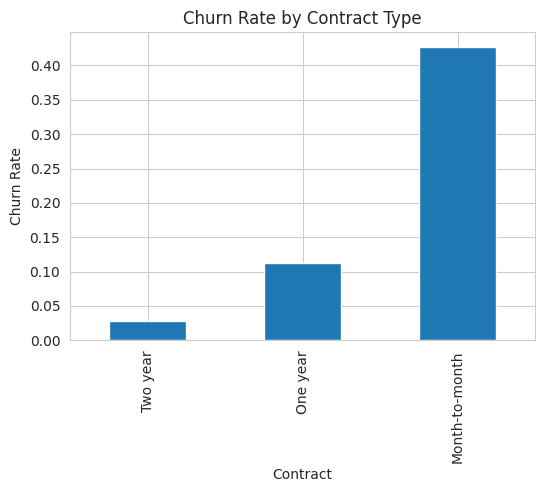

/tmp/ipykernel_1544/2798757818.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  telco_clean.groupby("tenure_bucket")["Churn"].mean().plot(kind="bar", color="coral")


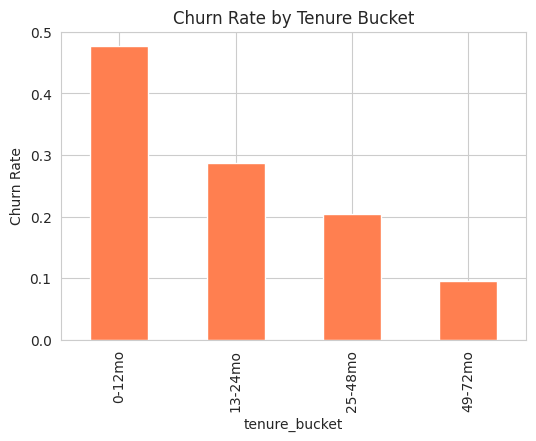

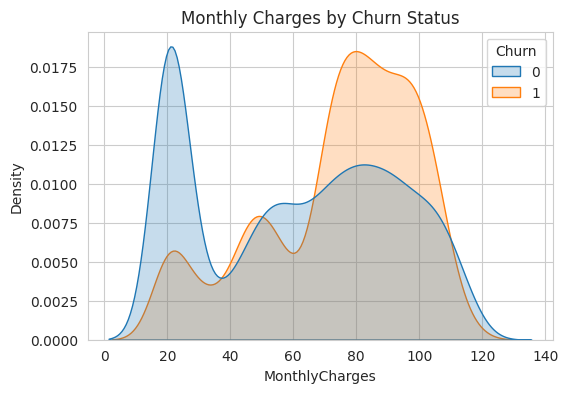

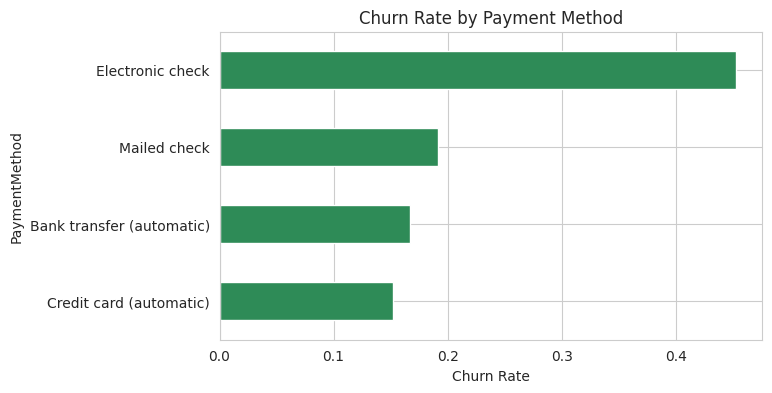

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

# Churn by contract type
plt.figure(figsize=(6,4))
telco_clean.groupby("Contract")["Churn"].mean().sort_values().plot(kind="bar")
plt.ylabel("Churn Rate"); plt.title("Churn Rate by Contract Type"); plt.show()

# Churn by tenure bucket
telco_clean["tenure_bucket"] = pd.cut(telco_clean["tenure"], bins=[0,12,24,48,72],
                                        labels=["0-12mo","13-24mo","25-48mo","49-72mo"])
plt.figure(figsize=(6,4))
telco_clean.groupby("tenure_bucket")["Churn"].mean().plot(kind="bar", color="coral")
plt.ylabel("Churn Rate"); plt.title("Churn Rate by Tenure Bucket"); plt.show()

# Monthly charges distribution by churn
plt.figure(figsize=(6,4))
sns.kdeplot(data=telco_clean, x="MonthlyCharges", hue="Churn", fill=True, common_norm=False)
plt.title("Monthly Charges by Churn Status"); plt.show()

# Churn by payment method
plt.figure(figsize=(7,4))
telco_clean.groupby("PaymentMethod")["Churn"].mean().sort_values().plot(kind="barh", color="seagreen")
plt.xlabel("Churn Rate"); plt.title("Churn Rate by Payment Method"); plt.show()

<Axes: xlabel='tenure_bucket'>

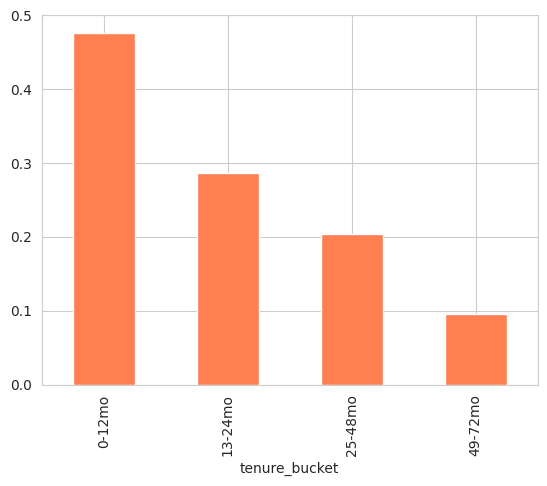

In [10]:
telco_clean.groupby("tenure_bucket", observed=False)["Churn"].mean().plot(kind="bar", color="coral")

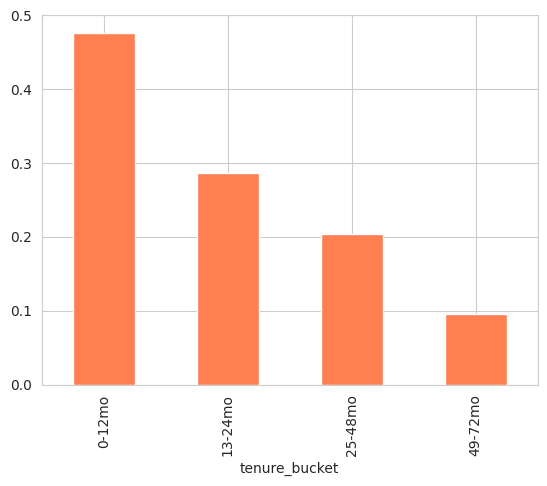

In [11]:
telco_clean.groupby("tenure_bucket", observed=False)["Churn"].mean().plot(kind="bar", color="coral");

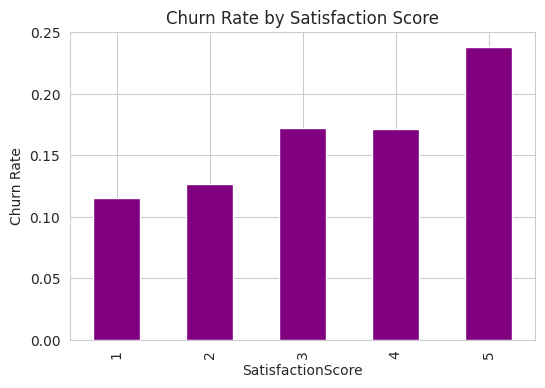

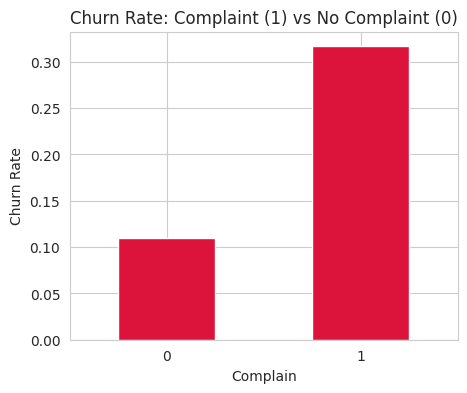

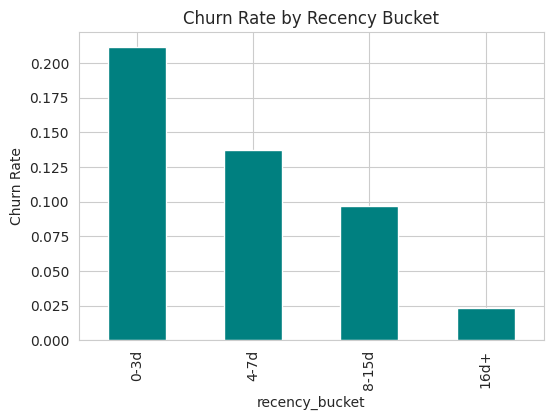

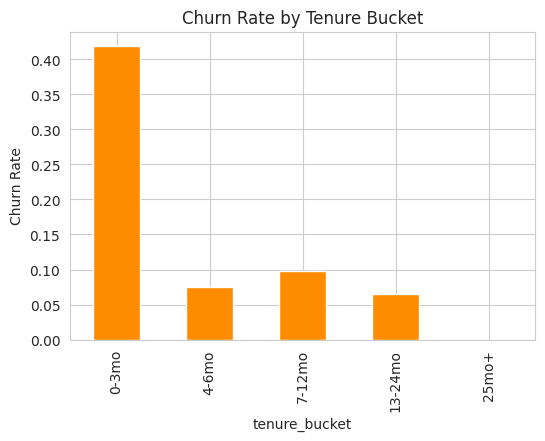

In [12]:
plt.figure(figsize=(6,4))
ecom_clean.groupby("SatisfactionScore")["Churn"].mean().plot(kind="bar", color="purple")
plt.ylabel("Churn Rate"); plt.title("Churn Rate by Satisfaction Score"); plt.show()

plt.figure(figsize=(5,4))
ecom_clean.groupby("Complain")["Churn"].mean().plot(kind="bar", color="crimson")
plt.ylabel("Churn Rate"); plt.title("Churn Rate: Complaint (1) vs No Complaint (0)"); plt.xticks(rotation=0); plt.show()

ecom_clean["recency_bucket"] = pd.cut(ecom_clean["DaySinceLastOrder"], bins=[-1,3,7,15,50],
                                        labels=["0-3d","4-7d","8-15d","16d+"])
plt.figure(figsize=(6,4))
ecom_clean.groupby("recency_bucket", observed=False)["Churn"].mean().plot(kind="bar", color="teal")
plt.ylabel("Churn Rate"); plt.title("Churn Rate by Recency Bucket"); plt.show()

ecom_clean["tenure_bucket"] = pd.cut(ecom_clean["Tenure"], bins=[-1,3,6,12,24,60],
                                       labels=["0-3mo","4-6mo","7-12mo","13-24mo","25mo+"])
plt.figure(figsize=(6,4))
ecom_clean.groupby("tenure_bucket", observed=False)["Churn"].mean().plot(kind="bar", color="darkorange")
plt.ylabel("Churn Rate"); plt.title("Churn Rate by Tenure Bucket"); plt.show()

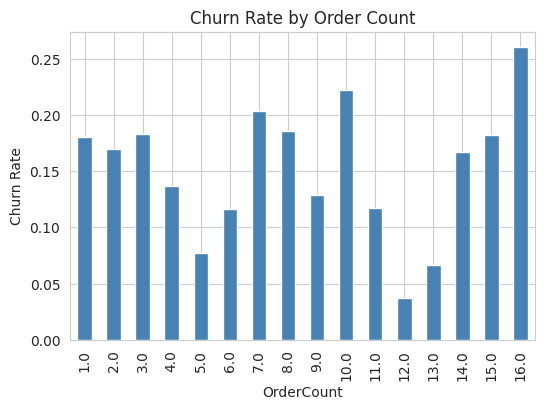

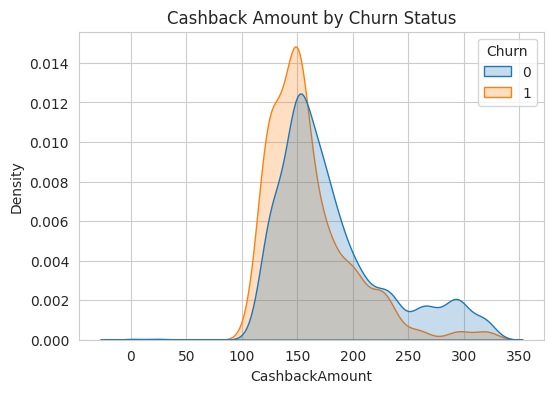

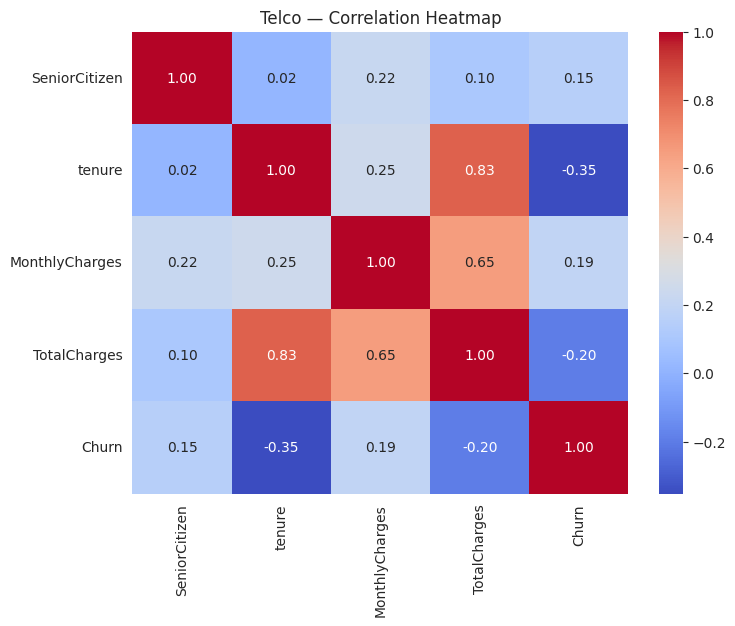

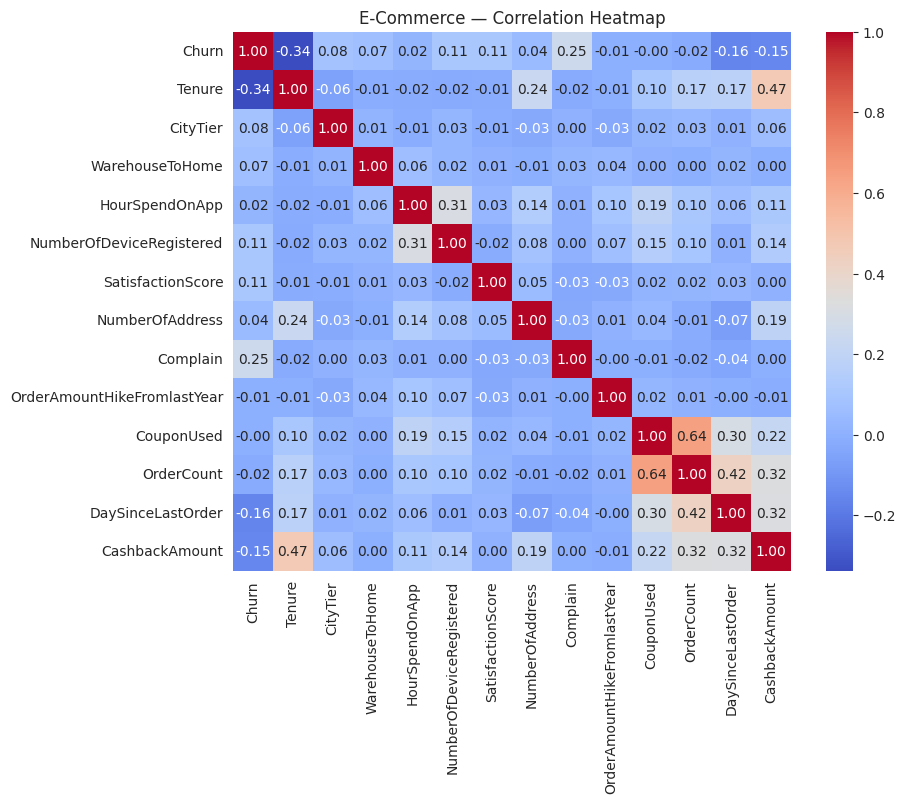

In [13]:
# Order frequency
plt.figure(figsize=(6,4))
ecom_clean.groupby("OrderCount")["Churn"].mean().plot(kind="bar", color="steelblue")
plt.ylabel("Churn Rate"); plt.title("Churn Rate by Order Count"); plt.show()

# Pricing signal (e-commerce)
plt.figure(figsize=(6,4))
sns.kdeplot(data=ecom_clean, x="CashbackAmount", hue="Churn", fill=True, common_norm=False)
plt.title("Cashback Amount by Churn Status"); plt.show()

# Correlation heatmaps
plt.figure(figsize=(8,6))
sns.heatmap(telco_clean.select_dtypes(include="number").corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Telco — Correlation Heatmap"); plt.show()

plt.figure(figsize=(9,7))
sns.heatmap(ecom_clean.select_dtypes(include="number").corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("E-Commerce — Correlation Heatmap"); plt.show()

In [14]:
import pandas as pd

# --- 1. Dataset comparison, computed not hardcoded ---
comparison = pd.DataFrame({
    "Telco": [len(telco_clean), telco_clean["Churn"].mean(), telco_clean.shape[1]],
    "E-Commerce": [len(ecom_clean), ecom_clean["Churn"].mean(), ecom_clean.shape[1]],
}, index=["Rows", "Churn Rate", "Num Features"])
print(comparison)

# --- 2. Rank numeric features by correlation with churn (per dataset) ---
telco_corr = telco_clean.select_dtypes(include="number").corr()["Churn"].drop("Churn").sort_values(key=abs, ascending=False)
ecom_corr = ecom_clean.select_dtypes(include="number").corr()["Churn"].drop("Churn").sort_values(key=abs, ascending=False)

print("\nTelco — features ranked by correlation with churn:")
print(telco_corr)
print("\nE-Commerce — features ranked by correlation with churn:")
print(ecom_corr)

# --- 3. Rank categorical features by churn-rate spread (max - min across categories) ---
def categorical_churn_spread(df, cat_cols):
    spreads = {}
    for col in cat_cols:
        rates = df.groupby(col)["Churn"].mean()
        spreads[col] = rates.max() - rates.min()
    return pd.Series(spreads).sort_values(ascending=False)

telco_cat_cols = telco_clean.select_dtypes(include="object").columns.tolist()
ecom_cat_cols = ecom_clean.select_dtypes(include="object").columns.tolist()

print("\nTelco — categorical features ranked by churn-rate spread:")
print(categorical_churn_spread(telco_clean, telco_cat_cols))
print("\nE-Commerce — categorical features ranked by churn-rate spread:")
print(categorical_churn_spread(ecom_clean, ecom_cat_cols))

# --- 4. Save handoff-ready CSVs with engineered buckets already included ---
telco_clean.to_csv("telco_cleaned_final.csv", index=False)
ecom_clean.to_csv("ecommerce_cleaned_final.csv", index=False)
print("\nSaved: telco_cleaned_final.csv, ecommerce_cleaned_final.csv")

                   Telco   E-Commerce
Rows          7043.00000  5630.000000
Churn Rate       0.26537     0.168384
Num Features    21.00000    21.000000

Telco — features ranked by correlation with churn:
tenure           -0.352229
TotalCharges     -0.198324
MonthlyCharges    0.193356
SeniorCitizen     0.150889
Name: Churn, dtype: float64

E-Commerce — features ranked by correlation with churn:
Tenure                        -0.337831
Complain                       0.250188
DaySinceLastOrder             -0.155871
CashbackAmount                -0.154118
NumberOfDeviceRegistered       0.107939
SatisfactionScore              0.105481
CityTier                       0.084703
WarehouseToHome                0.069544
NumberOfAddress                0.043931
OrderCount                    -0.024038
HourSpendOnApp                 0.018816
OrderAmountHikeFromlastYear   -0.007075
CouponUsed                    -0.001430
Name: Churn, dtype: float64

Telco — categorical features ranked by churn-rate spre